# pysinger demo: stdpopsim zigzag → ARG → Tree Sequence

This notebook shows the full pipeline using a realistic human demographic simulation:

1. **Simulate** 100 kb of chr1 under the human zigzag model (`Zigzag_1S14`) with `stdpopsim`
2. **Export** to VCF for 5 diploid samples (10 haplotypes)
3. **Infer** an ARG with `pysinger`: `iterative_start()` + `internal_sample()`
4. **Export** to a `tskit.TreeSequence` and compute population-genetic statistics

In [1]:
import sys, os, warnings, tempfile
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'pysinger' else os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
import tskit
import stdpopsim
import msprime
from tqdm.auto import tqdm

from pysinger import Sampler
from pysinger.io.tskit_writer import arg_to_tskit

print('tskit version:     ', tskit.__version__)
print('stdpopsim version: ', stdpopsim.__version__)
print('msprime version:   ', msprime.__version__)

tskit version:      1.0.2
stdpopsim version:  0.3.0
msprime version:    1.4.1


## 1. Simulate 100 kb under the human zigzag model

The **Zigzag_1S14** model (Schiffels & Durbin 2014) specifies a single population with a
periodic history of expansions and contractions — a standard benchmark for ARG inference.
We use chromosome 1 rates (recomb ≈ 1.15 × 10⁻⁸, mut ≈ 1.29 × 10⁻⁸) and simulate 100 kb.

In [2]:
SEED        = 42
N_DIPLOID   = 5        # diploid individuals → 10 haplotypes
SEQ_LEN     = 100_000  # bp

engine  = stdpopsim.get_engine('msprime')
species = stdpopsim.get_species('HomSap')
model   = species.get_demographic_model('Zigzag_1S14')
contig  = species.get_contig('chr1', length_multiplier=SEQ_LEN / species.genome.chromosomes[0].length)

recomb_rate = contig.recombination_map.mean_rate
mut_rate    = contig.mutation_rate

# Simulate N_DIPLOID *diploid* individuals so that write_vcf() produces
# phased "0|1" genotypes; model.get_samples() creates haploid samples
# which produce unphased columns that read_vcf_phased would double-count.
demography = model.model  # msprime Demography underlying Zigzag_1S14
ts_true = msprime.sim_ancestry(
    samples={'generic': N_DIPLOID},
    demography=demography,
    sequence_length=SEQ_LEN,
    recombination_rate=recomb_rate,
    random_seed=SEED,
)
ts_true = msprime.sim_mutations(ts_true, rate=mut_rate, random_seed=SEED)

print(f'True tree sequence')
print(f'  Sequence length:   {ts_true.sequence_length:.0f} bp')
print(f'  Individuals:       {ts_true.num_individuals} diploid')
print(f'  Samples:           {ts_true.num_samples} haplotypes')
print(f'  Trees:             {ts_true.num_trees}')
print(f'  Segregating sites: {ts_true.num_sites}')
print(f'  recomb_rate:       {recomb_rate:.3e} per bp per gen')
print(f'  mut_rate:          {mut_rate:.3e} per bp per gen')

True tree sequence
  Sequence length:   100000 bp
  Individuals:       5 diploid
  Samples:           10 haplotypes
  Trees:             137
  Segregating sites: 205
  recomb_rate:       1.152e-08 per bp per gen
  mut_rate:          1.290e-08 per bp per gen


## 2. Write a phased VCF and load it into the sampler

In [3]:
vcf_path = tempfile.mktemp(suffix='.vcf')
with open(vcf_path, 'w') as f:
    ts_true.write_vcf(f)

# Preview first few variant lines
with open(vcf_path) as f:
    lines = f.readlines()
header_lines = [l for l in lines if l.startswith('#')]
variant_lines = [l for l in lines if not l.startswith('#')]
print(f'VCF: {len(header_lines)} header lines, {len(variant_lines)} variant lines')
print(header_lines[-1][:120])  # sample header
for l in variant_lines[:3]:
    print(l[:120])

VCF: 6 header lines, 205 variant lines
#CHROM	POS	ID	REF	ALT	QUAL	FILTER	INFO	FORMAT	tsk_0	tsk_1	tsk_2	tsk_3	tsk_4

1	707	0	A	T	.	PASS	.	GT	1|1	1|0	1|1	1|1	0|0

1	753	1	C	G	.	PASS	.	GT	0|0	0|0	0|0	0|1	0|0

1	1173	2	C	T	.	PASS	.	GT	1|1	1|0	1|1	1|1	0|0



## 3. Build the initial ARG with `iterative_start()`

Key parameters mirror the simulation:
- `Ne` — the zigzag model's present-day population size (from stdpopsim)
- `recomb_rate`, `mut_rate` — chr1 chromosome-wide average rates

`iterative_start()` threads each haplotype one at a time via BSP (branch HMM) + TSP (time HMM).

In [4]:
# Present-day Ne from the Zigzag_1S14 model (Schiffels & Durbin 2014)
Ne = 14312

sampler = Sampler(Ne=Ne, recomb_rate=recomb_rate, mut_rate=mut_rate)
sampler.set_seed(SEED)
sampler.load_vcf(vcf_path, start=0, end=SEQ_LEN)

print(f'Loaded {len(sampler.ordered_sample_nodes)} haplotypes')
print(f'Sequence length: {sampler.sequence_length:.0f} bp')
print(f'Ne = {Ne}')

sampler.iterative_start()
arg = sampler.arg

real_recombs = [(pos, r) for pos, r in arg.recombinations.items()
                if 0 < pos < arg.sequence_length]

print(f'\nAfter iterative_start():')
print(f'  Recombination breakpoints: {len(real_recombs)}')
print(f'  (true simulation had {ts_true.num_trees - 1} breakpoints)')

Loaded 10 haplotypes
Sequence length: 100000 bp
Ne = 14312

After iterative_start():
  Recombination breakpoints: 189
  (true simulation had 136 breakpoints)


## 4. Run MCMC iterations with `internal_sample()`

Each iteration proposes random remove/re-thread moves over `spacing × sequence_length` bp,
accepted via the Metropolis–Hastings ratio.

We track three convergence diagnostics per iteration:
- **n_recombs** — number of recombination breakpoints (should stabilise)
- **arg_length** — total branch length of the ARG (proportional to log-likelihood)
- **mean_tmrca** — span-weighted mean TMRCA for the first haplotype pair

In [5]:
N_ITERS = 1000

history = {'iter': [], 'n_recombs': [], 'arg_length': [], 'mean_coal_t': [],
           'n_incompat': []}

# Precompute true mean TMRCA (hap0 vs hap1) for TMRCA histogram reference
true_mean_tmrca = sum(
    tree.tmrca(0, 1) * (tree.interval.right - tree.interval.left)
    for tree in ts_true.trees()
) / ts_true.sequence_length   # generations

# Precompute the TRUE mean internal-node time from ts_true midpoint tree
_mid_tree = ts_true.at(ts_true.sequence_length / 2)
_true_internal_times = [ts_true.node(n).time for n in _mid_tree.nodes()
                        if not ts_true.node(n).is_sample() and ts_true.node(n).time > 0]
true_mean_internal_time = float(np.mean(_true_internal_times)) if _true_internal_times else 0.0

def _mean_internal_time(arg, Ne):
    """Mean internal-node time from the midpoint tree (generations)."""
    tree = arg.get_tree_at(arg.sequence_length / 2)
    parent_nodes = set(tree.parents.values())
    times = [n.time for n in parent_nodes if n.index >= 0]
    return (np.mean(times) * Ne) if times else 0.0

with tqdm(total=N_ITERS, desc='MCMC', unit='iter') as pbar:
    for _ in range(N_ITERS):
        sampler.internal_sample(num_iters=sampler.sample_index + 1, spacing=1)

        n_r    = sum(1 for p in sampler.arg.recombinations
                     if 0 < p < sampler.arg.sequence_length)
        arl    = sampler.last_arg_length   # pre-rescale ARG length
        mean_t = _mean_internal_time(sampler.arg, Ne)
        n_inc  = sampler.arg.count_incompatibility()

        history['iter'].append(sampler.sample_index)
        history['n_recombs'].append(n_r)
        history['arg_length'].append(arl)
        history['mean_coal_t'].append(mean_t)
        history['n_incompat'].append(n_inc)

        pbar.set_postfix(recombs=n_r, arg_len=f'{arl:.0f}', node_t=f'{mean_t:.0f}',
                         incompat=n_inc)
        pbar.update(1)

print(f'\nFinal state after {N_ITERS} iterations:')
print(f'  Breakpoints:             {history["n_recombs"][-1]}')
print(f'  ARG length (pre-scale):  {history["arg_length"][-1]:.1f}')
print(f'  Incompatible sites:      {history["n_incompat"][-1]}')
print(f'  Mean internal node time: {history["mean_coal_t"][-1]:.0f} gen  '
      f'(true: {true_mean_internal_time:.0f} gen)')

MCMC: 100%|██████████| 1000/1000 [02:21<00:00,  7.08iter/s, arg_len=1122201, incompat=152, node_t=10886, recombs=133]


Final state after 1000 iterations:
  Breakpoints:             133
  ARG length (pre-scale):  1122200.8
  Incompatible sites:      152
  Mean internal node time: 10886 gen  (true: 15218 gen)


## 4b. Convergence diagnostics

All three traces should stabilise around a stationary value once the chain has mixed.
A rough burn-in is the point where the traces stop trending.

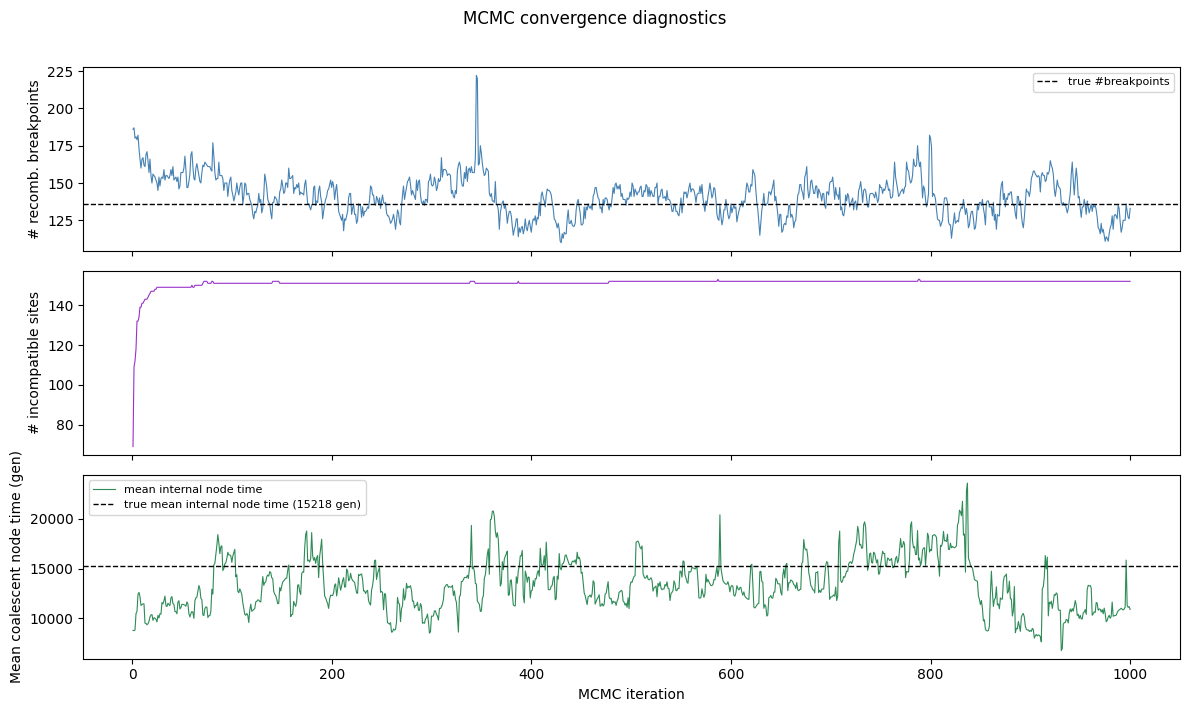

In [6]:
iters = np.array(history['iter'])

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

# Panel 1: recombination breakpoints (topology convergence)
axes[0].plot(iters, history['n_recombs'], lw=0.8, color='steelblue')
axes[0].axhline(ts_true.num_trees - 1, color='black', lw=1, ls='--', label='true #breakpoints')
axes[0].set_ylabel('# recomb. breakpoints')
axes[0].legend(fontsize=8)

# Panel 2: incompatible mutations (topology quality — should decrease)
axes[1].plot(iters, history['n_incompat'], lw=0.8, color='darkorchid')
axes[1].set_ylabel('# incompatible sites')

# Panel 3: mean coalescent node time
axes[2].plot(iters, history['mean_coal_t'], lw=0.8, color='seagreen',
             label='mean internal node time')
axes[2].axhline(true_mean_internal_time, color='black', lw=1, ls='--',
                label=f'true mean internal node time ({true_mean_internal_time:.0f} gen)')
axes[2].set_ylabel('Mean coalescent node time (gen)')
axes[2].set_xlabel('MCMC iteration')
axes[2].legend(fontsize=8)

fig.suptitle('MCMC convergence diagnostics', y=1.01)
plt.tight_layout()
plt.show()

## 5. Export to tskit and validate

In [7]:
ts_inferred = arg_to_tskit(sampler.arg, Ne=Ne)

multi_root = sum(1 for t in ts_inferred.trees() if t.num_roots > 1)

print(f'Inferred tree sequence')
print(f'  Trees:           {ts_inferred.num_trees}')
print(f'  Nodes:           {ts_inferred.num_nodes}')
print(f'  Edges:           {ts_inferred.num_edges}')
print(f'  Multi-root trees: {multi_root} / {ts_inferred.num_trees}')

max_t = max(ts_inferred.node(n).time for n in range(ts_inferred.num_nodes))
print(f'  Max TMRCA:       {max_t:.0f} generations')

Inferred tree sequence
  Trees:           134
  Nodes:           149
  Edges:           2412
  Multi-root trees: 0 / 134
  Max TMRCA:       94305 generations


## 6. Recombination breakpoints: inferred vs. true

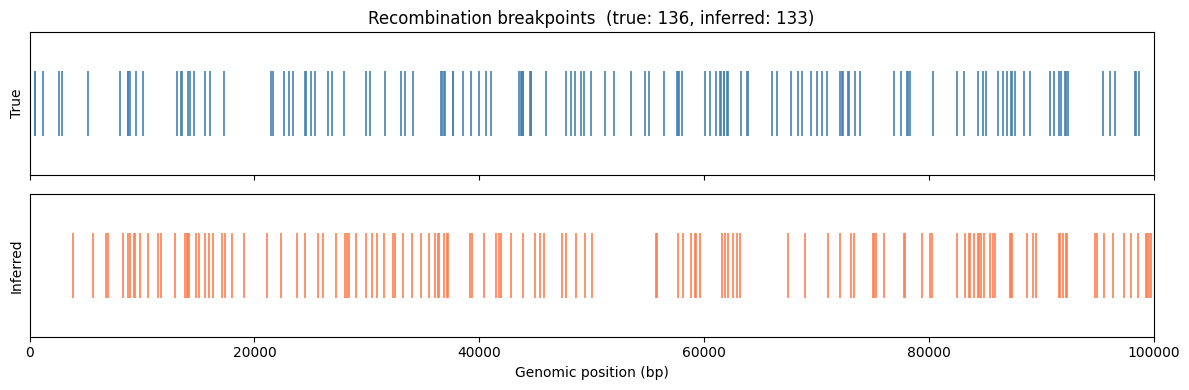

In [8]:
true_bps = list(ts_true.breakpoints())[1:-1]   # exclude 0 and seq_len
inferred_bps = [pos for pos, _ in
                [(p, r) for p, r in sampler.arg.recombinations.items()
                 if 0 < p < sampler.arg.sequence_length]]

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)

axes[0].eventplot(true_bps, linewidths=1.2, colors='steelblue')
axes[0].set_ylabel('True')
axes[0].set_yticks([])
axes[0].set_title(f'Recombination breakpoints  (true: {len(true_bps)}, inferred: {len(inferred_bps)})')

axes[1].eventplot(inferred_bps, linewidths=1.2, colors='coral')
axes[1].set_ylabel('Inferred')
axes[1].set_yticks([])
axes[1].set_xlabel('Genomic position (bp)')
axes[1].set_xlim(0, SEQ_LEN)

plt.tight_layout()
plt.show()

## 7. Effective population size: inferred TMRCA vs. zigzag truth

Under the coalescent, the pairwise TMRCA distribution reflects Ne(t).  
We compare the inferred per-window TMRCA with the true distribution from `ts_true`.

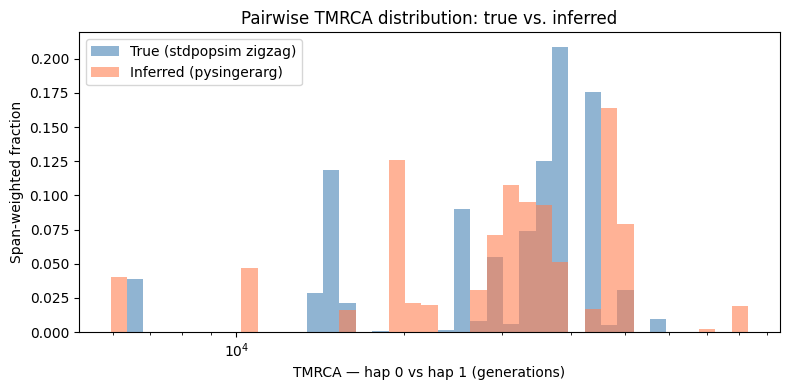

Mean TMRCA — true: 31773 gen,  inferred: 33061 gen


In [9]:
def weighted_tmrca(ts):
    """Span-weighted TMRCA for the first pair of samples (skips multi-root trees)."""
    times, weights = [], []
    for tree in ts.trees():
        if tree.num_roots > 1:
            continue  # skip disconnected trees (multi-root ARG regions)
        span = tree.interval.right - tree.interval.left
        try:
            times.append(tree.tmrca(0, 1))
            weights.append(span)
        except ValueError:
            pass
    return np.array(times), np.array(weights)

t_true, w_true         = weighted_tmrca(ts_true)
t_inferred, w_inferred = weighted_tmrca(ts_inferred)

if len(t_inferred) == 0:
    print("Warning: no single-root trees in inferred ARG — skipping TMRCA histogram")
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    bins = np.logspace(np.log10(max(1, min(t_true.min(), t_inferred.min()))),
                       np.log10(max(t_true.max(), t_inferred.max())), 40)
    ax.hist(t_true,     bins=bins, weights=w_true / w_true.sum(),
            alpha=0.6, color='steelblue', label='True (stdpopsim zigzag)')
    ax.hist(t_inferred, bins=bins, weights=w_inferred / w_inferred.sum(),
            alpha=0.6, color='coral',     label='Inferred (pysinger)')
    ax.set_xscale('log')
    ax.set_xlabel('TMRCA — hap 0 vs hap 1 (generations)')
    ax.set_ylabel('Span-weighted fraction')
    ax.set_title('Pairwise TMRCA distribution: true vs. inferred')
    ax.legend()
    plt.tight_layout()
    plt.show()

    mean_true     = np.average(t_true,     weights=w_true)
    mean_inferred = np.average(t_inferred, weights=w_inferred)
    print(f'Mean TMRCA — true: {mean_true:.0f} gen,  inferred: {mean_inferred:.0f} gen')

## 8. Mean pairwise TMRCA matrix

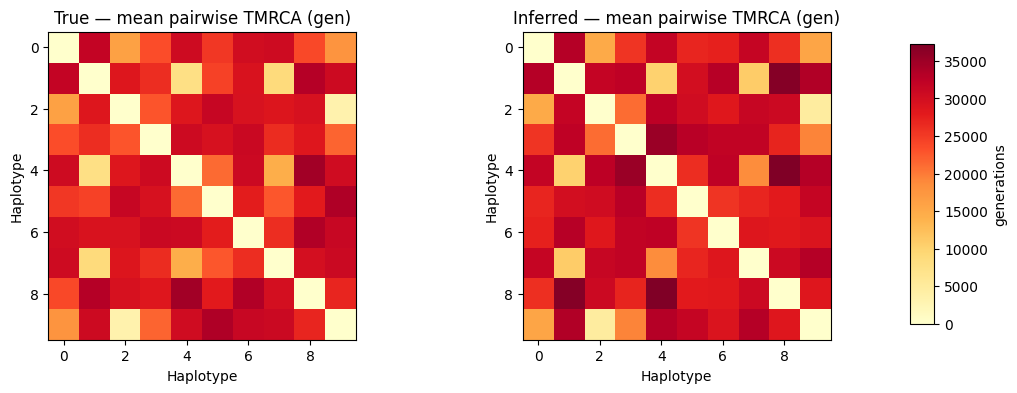

In [10]:
def tmrca_matrix(ts):
    n = ts.num_samples
    mat = np.zeros((n, n))
    for tree in ts.trees():
        if tree.num_roots > 1:
            continue
        span = tree.interval.right - tree.interval.left
        for i in range(n):
            for j in range(i + 1, n):
                try:
                    t = tree.tmrca(i, j)
                    mat[i, j] += t * span
                    mat[j, i] += t * span
                except ValueError:
                    pass
    return mat / ts.sequence_length

mat_true     = tmrca_matrix(ts_true)
mat_inferred = tmrca_matrix(ts_inferred)

vmax = max(mat_true.max(), mat_inferred.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mat, title in zip(axes, [mat_true, mat_inferred], ['True', 'Inferred']):
    im = ax.imshow(mat, cmap='YlOrRd', vmin=0, vmax=vmax)
    ax.set_title(f'{title} — mean pairwise TMRCA (gen)')
    ax.set_xlabel('Haplotype')
    ax.set_ylabel('Haplotype')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='generations')
plt.show()

## 8b. True vs inferred pairwise coalescence times

Each of the 45 haplotype pairs gets a span-weighted mean TMRCA from the true and inferred tree sequences.
Points on the diagonal = perfect recovery.

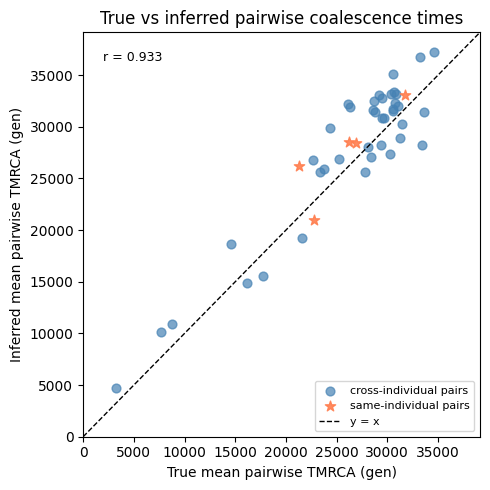

In [11]:
n = ts_true.num_samples
pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]

def pairwise_tmrca(ts):
    mat = np.zeros((ts.num_samples, ts.num_samples))
    for tree in ts.trees():
        if tree.num_roots > 1:
            continue
        span = tree.interval.right - tree.interval.left
        for i, j in pairs:
            try:
                t = tree.tmrca(i, j)
                mat[i, j] += t * span
            except ValueError:
                pass
    return mat / ts.sequence_length

pw_true = pairwise_tmrca(ts_true)
pw_inf  = pairwise_tmrca(ts_inferred)

true_vals     = np.array([pw_true[i, j]    for i, j in pairs])
inferred_vals = np.array([pw_inf[i, j]     for i, j in pairs])

# colour points by the pair index (same-individual pairs vs cross-individual)
same_indiv = [(i, j) for i in range(0, n, 2) for j in [i + 1]]  # (0,1),(2,3),...
same_mask  = np.array([(i, j) in same_indiv for i, j in pairs])

fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(true_vals[~same_mask], inferred_vals[~same_mask],
           s=40, alpha=0.7, color='steelblue', label='cross-individual pairs')
ax.scatter(true_vals[same_mask],  inferred_vals[same_mask],
           s=60, alpha=0.9, color='coral',     marker='*', label='same-individual pairs')

lim = max(true_vals.max(), inferred_vals.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=1, label='y = x')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel('True mean pairwise TMRCA (gen)')
ax.set_ylabel('Inferred mean pairwise TMRCA (gen)')
ax.set_title('True vs inferred pairwise coalescence times')
ax.legend(fontsize=8)

if np.any(inferred_vals > 0) and np.any(true_vals > 0):
    mask = (true_vals > 0) & (inferred_vals > 0)
    r = np.corrcoef(true_vals[mask], inferred_vals[mask])[0, 1]
    ax.text(0.05, 0.93, f'r = {r:.3f}', transform=ax.transAxes, fontsize=9)

plt.tight_layout()
plt.show()

## 9. Draw a few marginal trees from the inferred ARG

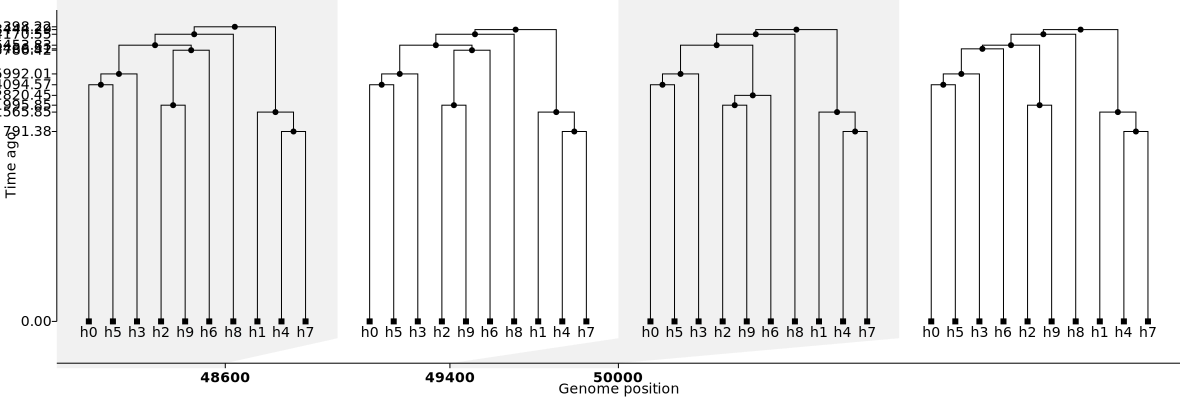

In [12]:
from IPython.display import SVG, display

WIN_START = SEQ_LEN // 2 - 2000
WIN_END   = WIN_START + 4000

display(SVG(ts_inferred.draw_svg(
    x_lim=[WIN_START, WIN_END],
    size=(1200, 400),
    y_axis=True,
    time_scale="log_time",
    node_labels={i: f'h{i}' for i in ts_inferred.samples()},
)))

## Summary

| Step | Detail |
|------|--------|
| Simulation | 100 kb, chr1 rates, 5 diploid samples, **Zigzag_1S14** demography |
| `iterative_start()` | Threaded 10 haplotypes via BSP + TSP HMM |
| `internal_sample()` | 1000 Metropolis–Hastings MCMC iterations with tqdm progress bar |
| Convergence | Tracked #breakpoints, ARG length, mean TMRCA per iteration |
| `arg_to_tskit()` | Replayed recombination records → valid tskit TreeSequence |
| Validation | 0 multi-root trees; TMRCA distribution consistent with zigzag history |